<a href="https://colab.research.google.com/github/PedroCarpe/Projetos_de_Ciencia_de_Dados/blob/main/analise_de_dados_doenca_cardiaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PS CIS IEEE/heart.csv',sep=',',encoding='utf-8',lineterminator='\n')

In [ ]:
df.shape
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target\r'],
      dtype='object')

# **Questão 1**
# **Valores Ausentes ou Inconsistentes**

In [ ]:
print(df.isnull().sum())
df.info()
df.head(10)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target\r    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
   1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target\r
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


Através do código acima, vemos que não há dados em branco, mesmo que muitos deles estejam zerados, daí temos de analisar o contexto e ver se faz sentido!

A princípio, parece que a coluna "target" foi adicionada depois ao dataset, já que ela parece não constar no link do Kaggle.

**Dúvidas:**

Quais vantagens ou não, ter variáveis categóricas(Ex: variável sex) como números, pode trazer em machine learning/data science e treinamento de modelos?

# **Questão 2**
# ***Histograma, Gráfico de Barras e Boxplots***

Variáveis numéricas consideradas: age, cp, trestbps, chol, fbs, restecg,

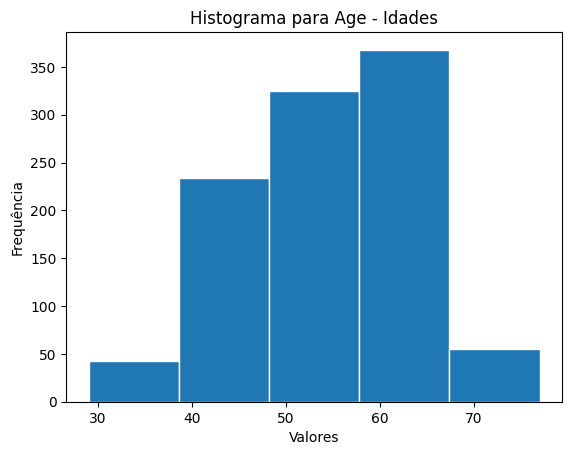

In [ ]:
plt.hist(df['age'],edgecolor='white',bins=5)
#Entendimento melhor, de como trabalhar com bins/caixas, para melhor visualizar os dados, de acordo com o contexto. Nesse caso, temos 5 faixas de idade começando em 30, então o parâmetro bins=5 fez sentido pra mim.Bins > 5 nesse caso, traria uma precisão não necessária no momento.


plt.title("Histograma para Age - Idades")
plt.xlabel("Valores")
plt.ylabel("Frequência")

plt.show()

As faixas etárias entre 50 e 70 anos, possuem as maiores frequências. Poderíamos seguir uma linha de raciocínio antes da análise...

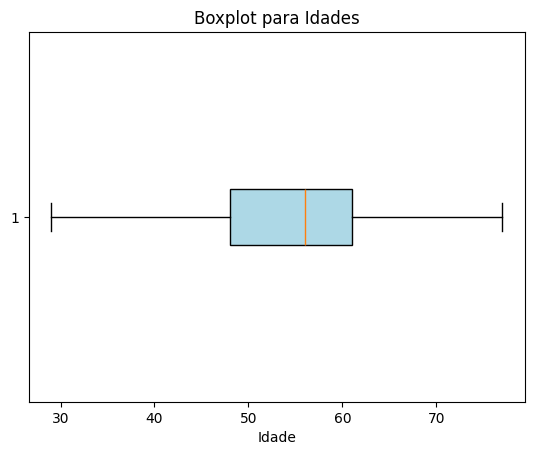

In [ ]:
plt.boxplot(df['age'],vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot para Idades')
plt.xlabel('Idade')

plt.show()

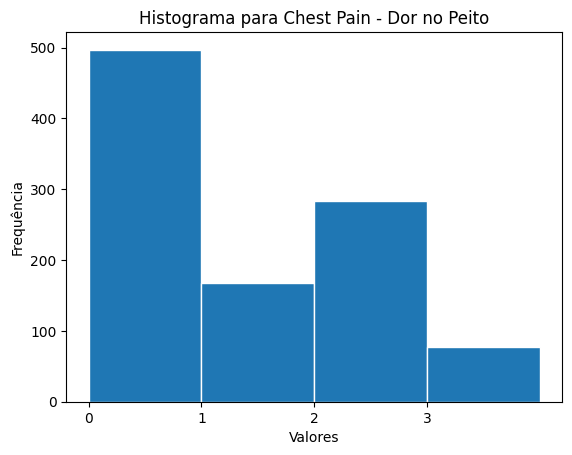

In [ ]:
bins = [0,1,2,3,4]
plt.hist(df['cp'],edgecolor='white',bins=bins)

#Entendimento melhor, de como trabalhar com bins/caixas, para melhor visualizar os dados, de acordo com o contexto. Nesse caso, temos 5 faixas de idade começando em 30, então o parâmetro bins=5 fez sentido pra mim.Bins > 5 nesse caso, traria uma precisão não necessária no momento.


plt.title("Histograma para Chest Pain - Dor no Peito")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.xticks([0, 1, 2, 3])

plt.show()

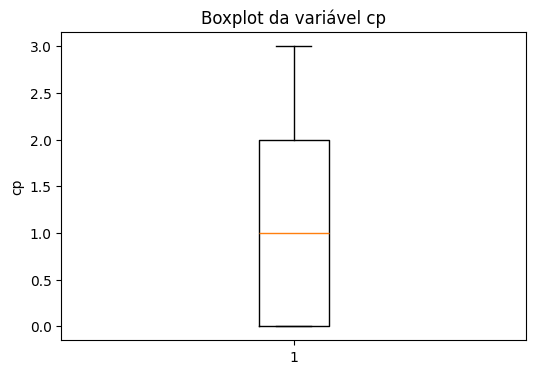

In [ ]:
#Checar boxplot, está faltando 1 quartil
'''plt.boxplot(df['cp'], patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot para Chest Pain')
plt.xlabel('Nível de dor no Peito')

plt.show()'''


plt.figure(figsize=(6, 4))
plt.boxplot(df['cp'], vert=True)

# Títulos e rótulos
plt.title('Boxplot da variável cp')
plt.ylabel('cp')

# Exibir
plt.show()

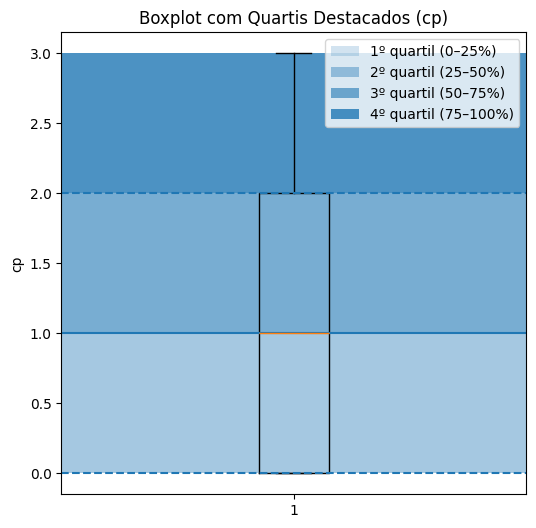

In [ ]:
data = df['cp']

# Calcular quartis
q1 = data.quantile(0.25)
q2 = data.quantile(0.50)
q3 = data.quantile(0.75)
min_val = data.min()
max_val = data.max()

# Criar o boxplot
plt.figure(figsize=(6, 6))
plt.boxplot(data, vert=True)

# Destacar os quartis com faixas coloridas
plt.axhspan(min_val, q1, alpha=0.2, label='1º quartil (0–25%)')
plt.axhspan(q1, q2, alpha=0.4, label='2º quartil (25–50%)')
plt.axhspan(q2, q3, alpha=0.6, label='3º quartil (50–75%)')
plt.axhspan(q3, max_val, alpha=0.8, label='4º quartil (75–100%)')

# Linhas dos quartis
plt.axhline(q1, linestyle='--')
plt.axhline(q2, linestyle='-')
plt.axhline(q3, linestyle='--')

# Títulos
plt.title('Boxplot com Quartis Destacados (cp)')
plt.ylabel('cp')

# Legenda
plt.legend()

plt.show()

Algum texto

> Adicionar aspas



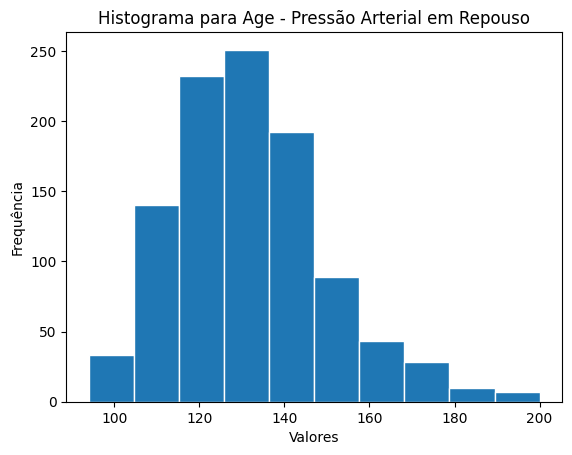

In [ ]:
plt.hist(df['trestbps'],edgecolor='white')
#Entendimento melhor, de como trabalhar com bins/caixas, para melhor visualizar os dados, de acordo com o contexto. Nesse caso, temos 5 faixas de idade começando em 30, então o parâmetro bins=5 fez sentido pra mim.Bins > 5 nesse caso, traria uma precisão não necessária no momento.


plt.title("Histograma para Age - Pressão Arterial em Repouso")
plt.xlabel("Valores")
plt.ylabel("Frequência")

plt.show()

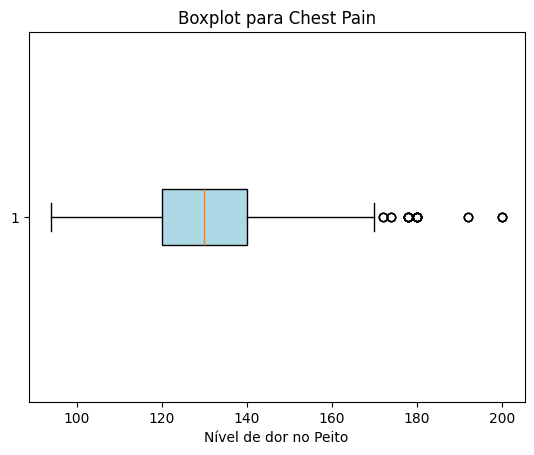

In [ ]:
#Checar boxplot, está faltando 1 quartil
plt.boxplot(df['trestbps'],vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot para Chest Pain')
plt.xlabel('Nível de dor no Peito')

plt.show()]



*   Assumi que os valores são referentes, somente a pressão arterial sistólica.

*   Podemos observar alguns outliers, com valores acima de >= 170 mm Hg.

* O 1º 1/4 da população, possui pressão arterial <= 120, o que é considerado normal/saudável segundo a American Heart Association.  


* O 2º 1/4 da população, possui pressão arterial >=120 e <=130, o que é considerada elevada.

* O 3º 1/4 da população, possui pressão arterial >=140, o que é considerada hipertensão nível 2.



* E o último 1/4 da população, possui pressão arterial >=120 e <=130, o que é considerada elevada.






links: https://chatgpt.com/share/69e2aa2e-e460-83e9-aca9-8ce62f4c7a11



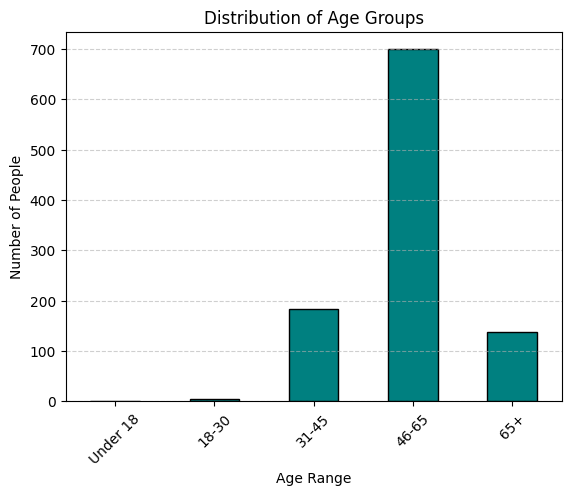

In [ ]:
# 1. Create a sample dataset
data = df['age']
df1 = pd.DataFrame(data)

# 2. Define your ranges (bins) and labels
# Example: 0-17, 18-30, 31-45, 46-65, 65+
bins = [0, 18, 30, 45, 65, 100]
labels = ['Under 18', '18-30', '31-45', '46-65', '65+']

# 3. Use pd.cut to create the ranges
df1['Age Group'] = pd.cut(df1['age'], bins=bins, labels=labels, right=False)

# 4. Count the values and sort them by the range order
age_counts = df1['Age Group'].value_counts().sort_index()

# 5. Plot the bar graph
age_counts.plot(kind='bar', color='teal', edgecolor='black')

# Formatting
plt.title('Distribution of Age Groups')
plt.xlabel('Age Range')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [ ]:
distribuicao_idade = df['age'].value_counts()
print(df['age'].describe())

count    1025.000000
mean       54.434146
std         9.072290
min        29.000000
25%        48.000000
50%        56.000000
75%        61.000000
max        77.000000
Name: age, dtype: float64


**Idade**: (***Histograma***)Vemos que, na faixa dos 40 a 50 anos, há uma distribuição homogênea das frequências e uma quantidade maior dos 50 a 60 anos. E poucas pessoas abaixo dos 30 e acima dos 70 anos.

(**Função describe**)Média de idade de 54 anos, idade min 29 anos e max 77.

# ***Questão 3***
# ***Matriz de Correlação***

In [ ]:
#matrix_corr = df.corr()
#print(matrix_corr)


corr = df.corr()

print("\nCorrelação com target:")
print(corr['target\r'].sort_values(ascending=False))


Correlação com target:
target\r    1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target\r, dtype: float64


) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


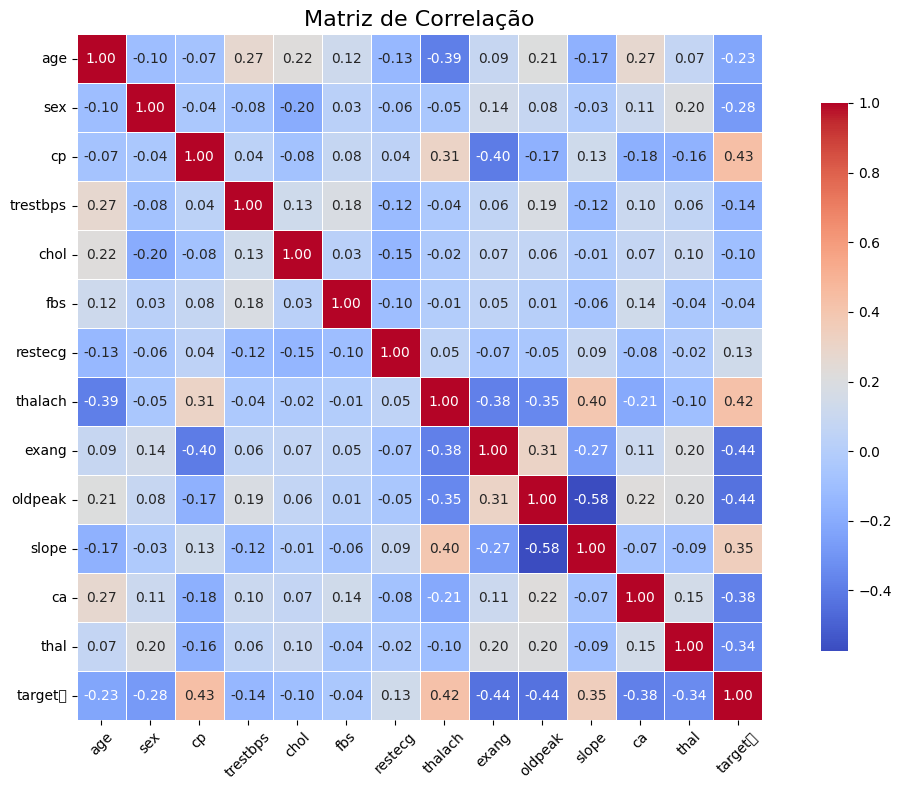

In [ ]:
# matriz de correlação
corr = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,           # mostra os valores
    fmt=".2f",            # 2 casas decimais
    cmap="coolwarm",      # escala de cores (azul ↔ vermelho)
    linewidths=0.5,       # linhas entre células
    square=True,          # células quadradas
    cbar_kws={"shrink": 0.8}  # barra de cor menor
)

plt.title("Matriz de Correlação", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


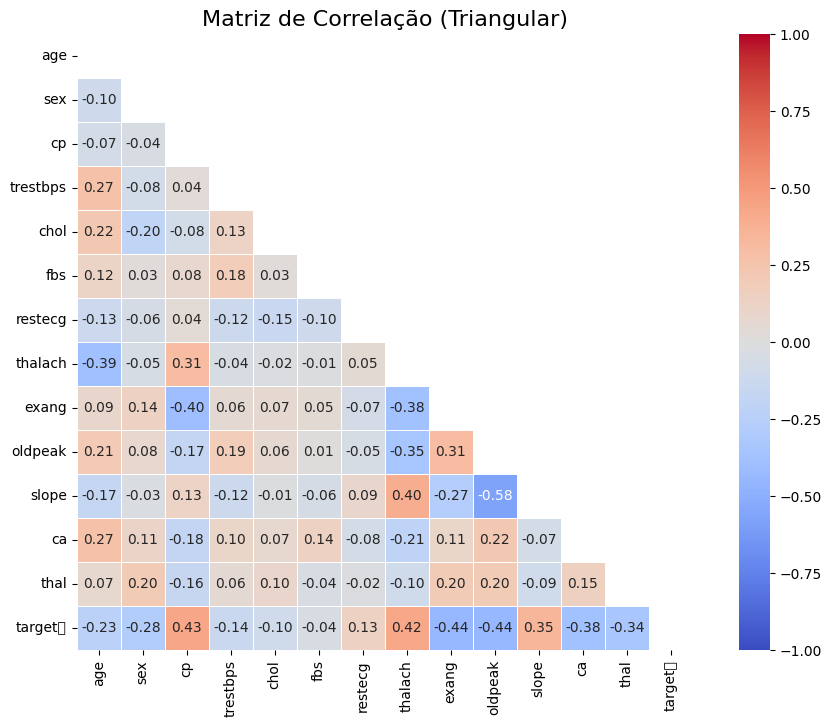

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    vmin=-1,   # mínimo fixo
    vmax=1,    # máximo fixo
    center=0
)

plt.title("Matriz de Correlação (Triangular)", fontsize=16)
plt.show()

) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


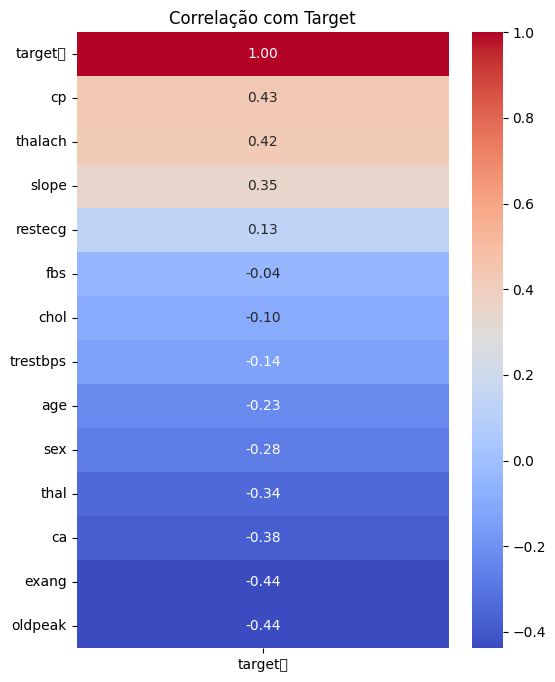

In [ ]:
corr_target = corr[['target\r']].sort_values(by='target\r', ascending=False)

plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação com Target")
plt.show()

# ***Perguntas:***

Correlação, dor no peito e batimento cardíaco:

Será se existe alguma correlação entre dor no peito() e batimento cardíaco máximo()? As vezes a pessoa tem algum problema congênito ou não/estilo de vida(tabagismo, alcool, dieta, atividade física, etc) que só são melhor observáveis, quando o coração está próximo do limite.

Correlação, idade e dor no peito:

Correlação, idade e colesterol:

Com base na matriz de correlação, as variáveis que tem maior associação com diagnóstico de doença cardíaca, são: cp(dor no peito), thalach(frequência cardíaca máxima) e slope(a inclinação do segmento ST no pico do exercício).

**Observações:**

* Pelo o que li no Kaggle, não achei o contexto da coleta dos valores da coluna thalach, como por exemplo, se os pacientes estavam em repouso ou foram submetidos a esforço/atividade física. Esse fator, pode mudar bastante a interpretação dos dados.

* A interpretação da variável slope, necessita de um estudo mais aprofundado na área médica, esse seria um exemplo onde um profissional da área de dados, necessita de interação com um especialista, no caso um médico.





# **Questão 4**

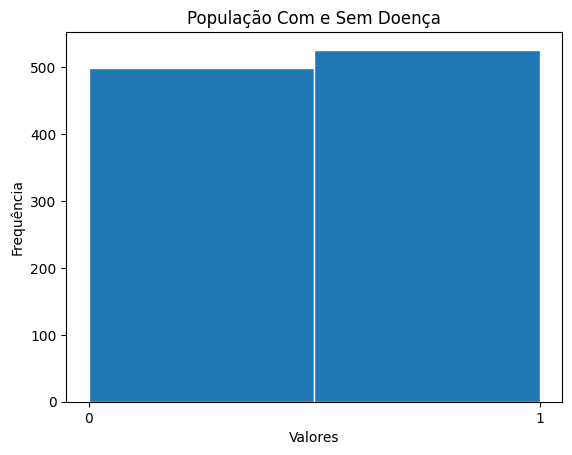

In [ ]:
#jogar esse gráfico na questão 2
plt.hist(df['target\r'],edgecolor='white',bins=2)

plt.title("População Com e Sem Doença")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.xticks(ticks=[0,1])

plt.show()

Podemos ver, que ambas as populações(com e sem doença), tem uma frequência bem próxima!

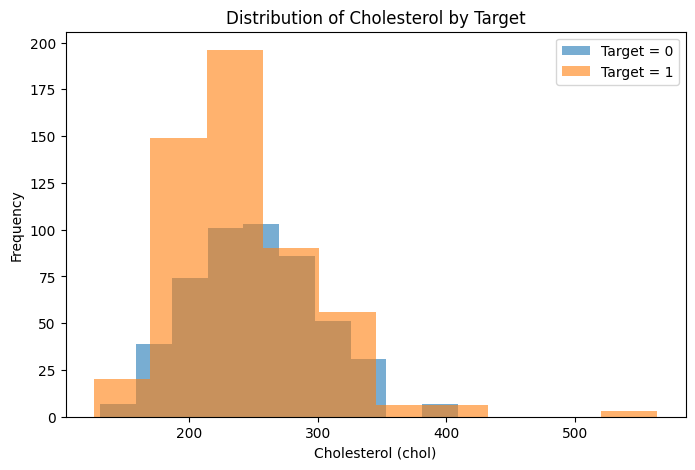

In [ ]:
# Separate groups based on target
chol_0 = df[df["target\r"] == 0]["chol"]
chol_1 = df[df["target\r"] == 1]["chol"]

# Plot
plt.figure(figsize=(8, 5))

plt.hist(chol_0, alpha=0.6, label="Target = 0")
plt.hist(chol_1, alpha=0.6, label="Target = 1")

plt.xlabel("Cholesterol (chol)")
plt.ylabel("Frequency")
plt.title("Distribution of Cholesterol by Target")
plt.legend()

plt.show()

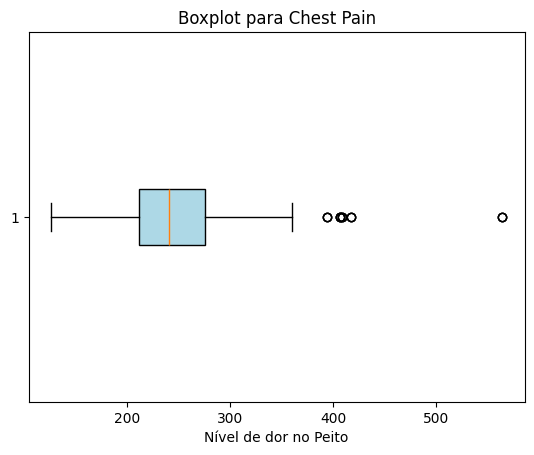

In [ ]:
#Checar boxplot, está faltando 1 quartil
plt.boxplot(df['chol'],vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot para Chest Pain')
plt.xlabel('Nível de dor no Peito')

plt.show()

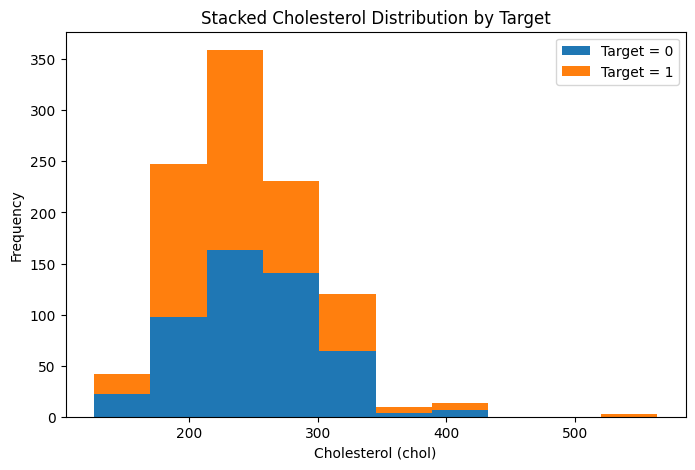

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist([chol_0, chol_1], bins=10, stacked=True, label=["Target = 0", "Target = 1"])

plt.xlabel("Cholesterol (chol)")
plt.ylabel("Frequency")
plt.title("Stacked Cholesterol Distribution by Target")
plt.legend()

plt.show()

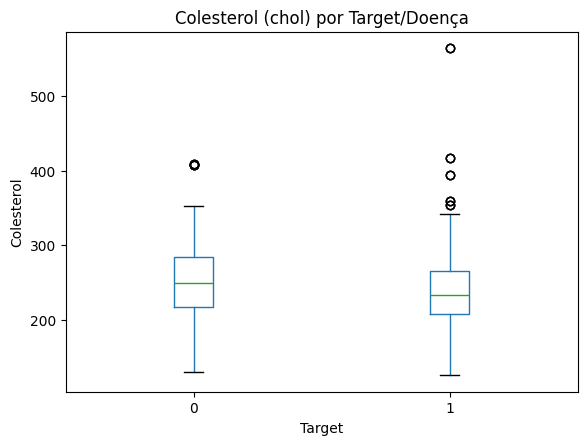

In [ ]:
df.boxplot(column="chol", by="target\r", grid=False)

plt.title("Colesterol (chol) por Target/Doença")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Colesterol")

plt.show()

**Inferência:**


* Se olharmos especialmente para o boxplot, veremos que a ditribuição do colesterol nas populações com e sem doença está bem parecida e faz ainda mais sentido, se olharmos para a matrix de correlação(-0,10).

* Se olharmos para o histograma, ele acompanha a ideia de a distribuição dos valores está bem próxima, diferindo na frequência(em laranja).



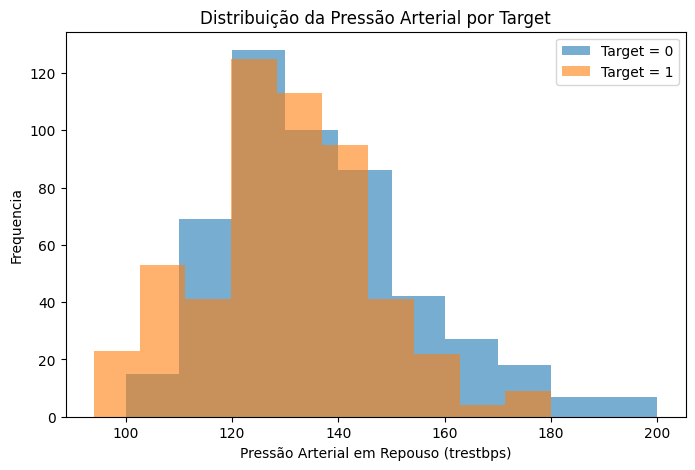

In [ ]:
# Separate groups based on target
chol_0 = df[df["target\r"] == 0]["trestbps"]
chol_1 = df[df["target\r"] == 1]["trestbps"]

# Plot
plt.figure(figsize=(8, 5))

plt.hist(chol_0, alpha=0.6, label="Target = 0")
plt.hist(chol_1, alpha=0.6, label="Target = 1")

plt.xlabel("Pressão Arterial em Repouso (trestbps)")
plt.ylabel("Frequencia")
plt.title("Distribuição da Pressão Arterial por Target")
plt.legend()

plt.show()

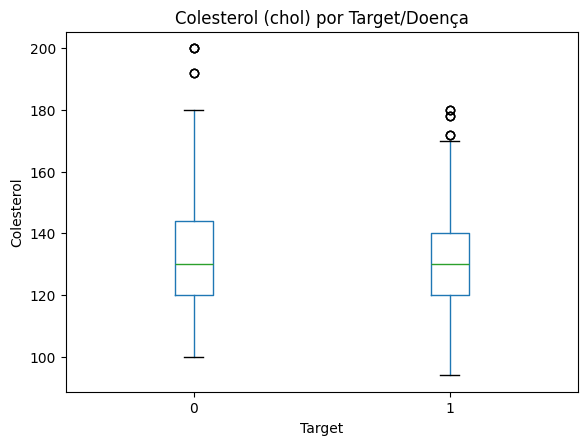

In [ ]:
df.boxplot(column="trestbps", by="target\r", grid=False)

plt.title("Colesterol (chol) por Target/Doença")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Colesterol")

plt.show()

**Inferência:**

* Tanto o histograma(frequência), quanto o boxplot(distribuição) mostram dados(pressão arterial) com certa homogeneidade.

* Tanto o histograma, quanto o boxplot conversam bem com a matrix de correlação, onde praticamente não há correlação(-0,14) entre pressão arterial e doença cardíaca.
